In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install textblob
!pip install wordcloud

In [4]:
from textblob import TextBlob             # for sentiment analysis,imporing specific tools
from wordcloud import WordCloud           # for creating wordcloud, importing specific tools

In [6]:
# Loading Data
data = pd.read_csv(r"C:\Users\akshat\Desktop\word cloud\Sentiment_Analysis .csv")

data.head(10)

,Sentences
0,The product's exceptional quality and performa...
1,Poor customer support and the product's subpar...
2,The service met standard requirements without ...
3,Outstanding customer service accompanied the p...
4,The product's failure to meet basic requiremen...
5,The service provided met basic needs without n...
6,Remarkable product quality and performance exc...
7,Poor customer service and a faulty product led...
8,"The service provided was average, meeting mini..."
9,"The purchase proved delightful, with the produ..."


In [7]:
# Define Sentiment Analysis Function

def get_sentiment(text):
    
    meaning = TextBlob(text)

    if meaning.sentiment.polarity > 0:
        return "Positive"

    elif meaning.sentiment.polarity < 0:
        return "Negetive"

    else:
        return "Neutral"

In [8]:
# Apply Sentiment Analysis

data["Sentiment"] = data["Sentences"].apply(get_sentiment)

In [9]:
data.head(20)

,Sentences,Sentiment
0,The product's exceptional quality and performa...,Positive
1,Poor customer support and the product's subpar...,Negetive
2,The service met standard requirements without ...,Positive
3,Outstanding customer service accompanied the p...,Positive
4,The product's failure to meet basic requiremen...,Negetive
5,The service provided met basic needs without n...,Positive
6,Remarkable product quality and performance exc...,Positive
7,Poor customer service and a faulty product led...,Negetive
8,"The service provided was average, meeting mini...",Negetive
9,"The purchase proved delightful, with the produ...",Positive


In [10]:
akshat = data["Sentiment"].value_counts()
print(akshat)

Sentiment
Positive    12
Negetive     9
Neutral      1
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

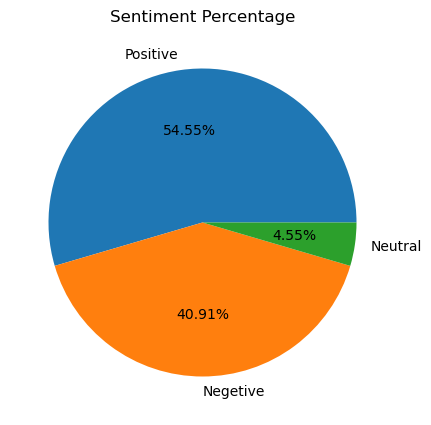

In [21]:
plt.figure(figsize=(10,5))
plt.pie(akshat, labels = akshat.index, autopct='%.2f%%')
plt.title("Sentiment Percentage")
plt.savefig("sentiment_pie_chart.png", dpi=300, bbox_inches="tight")
plt.show 

In [13]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [14]:
data.to_excel("C247_Sentiment.xlsx",index=False)

In [15]:
# Filtering all the negetive reviews

negetive_reviews= data[data["Sentiment"]=="Negetive"]

In [16]:
negetive_reviews.head(20)

,Sentences,Sentiment
1,Poor customer support and the product's subpar...,Negetive
4,The product's failure to meet basic requiremen...,Negetive
7,Poor customer service and a faulty product led...,Negetive
8,"The service provided was average, meeting mini...",Negetive
13,Dreadful customer support coupled with a defec...,Negetive
16,Severe product shortcomings led to considerabl...,Negetive
17,"The service was standard, meeting basic needs ...",Negetive
19,Disappointing product quality and poor custome...,Negetive
20,"The service provided was average, meeting basi...",Negetive


In [17]:
# Combine all negetive reviews into a single string.

all_negetiv_merged = " ".join(negetive_reviews["Sentences"])

In [18]:
print(all_negetiv_merged)

Poor customer support and the product's subpar performance led to frustration and disappointment, regretting the purchase entirely. The product's failure to meet basic requirements resulted in immense inconvenience and frustration, causing regret over the purchase. Poor customer service and a faulty product led to significant inconvenience and frustration, resulting in regret over the purchase decision. The service provided was average, meeting minimum requirements without standout features, resulting in a standard user experience. Dreadful customer support coupled with a defective product caused immense frustration and disappointment, regretting the purchase. Severe product shortcomings led to considerable dissatisfaction and regret over the purchase due to a lack of promised functionality. The service was standard, meeting basic needs without noteworthy features, resulting in an average user experience without extremes. Disappointing product quality and poor customer service resulted

In [19]:
# Create the word cloud for negetive review
Vortex = WordCloud(width=1000,height=500,background_color="black").generate(all_negetiv_merged)

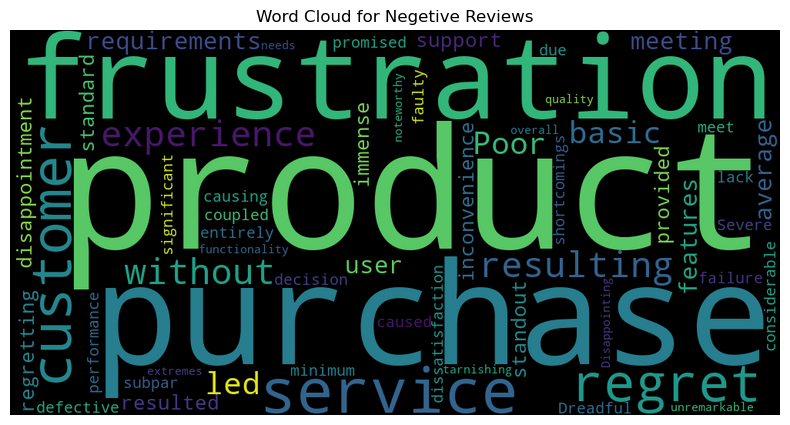

In [22]:
# Plot the Word Cloud

plt.figure(figsize=(10,5))
plt.imshow(Vortex,interpolation = "blackman")
plt.title("Word Cloud for Negetive Reviews")
plt.axis("off")
plt.savefig("negative_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()